# Final Project: Multi-Class Linear Discriminant Analysis (LDA) with Feature Selection


**Requirements Satisfied:**
- Implement multiple filter ranking metrics: Pearson, Spearman, Gini, Chi-Square, Information Gain
- Rank features using each metric
- Train Multi-class LDA using top-k features
- Compare stability and performance
- Analyze theoretical differences between criteria

**Dataset:** 
- Wine Dataset: 13 features, 3 classes, 0 missing values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

# Load wine dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

X = df.drop('target', axis=1)
y = df['target']

print("Dataset Shape:", df.shape)
print("Features:", X.shape[1])
print("Classes:", len(np.unique(y)))
print("Missing Values Check:", df.isnull().sum().sum())
df.head()

Dataset Shape: (178, 14)
Features: 13
Classes: 3
Missing Values Check: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 1. Pearson Correlation

In [2]:
# 1. Pearson Correlation Feature Ranking
print("\nPearson Correlation Feature Ranking ")
pearson_scores = {}
for col in X.columns:
    corr_value = X[col].corr(y)
    pearson_scores[col] = abs(corr_value)

pearson_ranking = pd.Series(pearson_scores).sort_values(ascending=False)
display(pearson_ranking)



Pearson Correlation Feature Ranking 


flavanoids                      0.847498
od280/od315_of_diluted_wines    0.788230
total_phenols                   0.719163
proline                         0.633717
hue                             0.617369
alcalinity_of_ash               0.517859
proanthocyanins                 0.499130
nonflavanoid_phenols            0.489109
malic_acid                      0.437776
alcohol                         0.328222
color_intensity                 0.265668
magnesium                       0.209179
ash                             0.049643
dtype: float64

## 2. Spearman Rank Correlation

In [3]:
# 2. Spearman Rank Correlation Feature Ranking
print("\n Spearman Rank Correlation Feature Ranking ")
spearman_scores = {}
for col in X.columns:
    corr_value = X[col].corr(y, method="spearman")
    spearman_scores[col] = abs(corr_value)

spearman_ranking = pd.Series(spearman_scores).sort_values(ascending=False)
display(spearman_ranking)



 Spearman Rank Correlation Feature Ranking 


flavanoids                      0.854908
od280/od315_of_diluted_wines    0.743787
total_phenols                   0.726544
hue                             0.616570
proline                         0.576383
proanthocyanins                 0.570648
alcalinity_of_ash               0.569792
nonflavanoid_phenols            0.474205
alcohol                         0.354167
malic_acid                      0.346913
magnesium                       0.250498
color_intensity                 0.131170
ash                             0.053988
dtype: float64

## 3. Gini Index

In [4]:
# 3. Gini Index Feature Ranking
class GiniFeatureSelector:
    def __init__(self, target_col, bins=5):
        self.target_col = target_col
        self.bins = bins
        self.gini_scores_ = {}

    def _gini(self, y_sub):
        counts = np.bincount(y_sub)
        probabilities = counts / len(y_sub)
        return 1 - np.sum(probabilities ** 2)

    def _weighted_gini(self, X_col, y_sub):
        unique_values, counts = np.unique(X_col, return_counts=True)
        weighted_gini = 0
        for value, count in zip(unique_values, counts):
            y_subset = y_sub[X_col == value]
            weight = count / len(y_sub)
            weighted_gini += weight * self._gini(y_subset)
        return weighted_gini

    def fit(self, df):
        y_vals = df[self.target_col].values
        for col in df.columns:
            if col == self.target_col: continue
            binned_feature = pd.cut(df[col], bins=self.bins, labels=False)
            X_col = binned_feature.values
            self.gini_scores_[col] = self._weighted_gini(X_col, y_vals)
        return self

print("\nGini Index Feature Ranking ")
gini_selector = GiniFeatureSelector(target_col="target", bins=5)
gini_selector.fit(df)
gini_ranking = pd.Series(gini_selector.gini_scores_).sort_values(ascending=True) # Lower is better
display(gini_ranking)


Gini Index Feature Ranking 


flavanoids                      0.297733
color_intensity                 0.365062
proline                         0.382828
od280/od315_of_diluted_wines    0.411704
alcohol                         0.423264
hue                             0.455662
total_phenols                   0.468600
magnesium                       0.523013
alcalinity_of_ash               0.550034
malic_acid                      0.552397
proanthocyanins                 0.559815
nonflavanoid_phenols            0.562133
ash                             0.603486
dtype: float64

## 4. Chi-Square Statistic

In [5]:
# 4. Chi-Square Statistic Feature Ranking
class ChiSquaredFeatureSelector:
    def __init__(self, target_col, bins=5):
        self.target_col = target_col
        self.bins = bins
        self.chi2_scores_ = {}

    def _chi_squared_stat(self, contingency_table):
        observed = contingency_table.values
        row_totals = observed.sum(axis=1)
        col_totals = observed.sum(axis=0)
        total = observed.sum()
        expected = np.outer(row_totals, col_totals) / total
        expected[expected == 0] = 1e-9 # avoid division by zero
        chi_squared = np.sum((observed - expected) ** 2 / expected)
        return chi_squared

    def fit(self, df):
        y_vals = df[self.target_col]
        for col in df.columns:
            if col == self.target_col: continue
            binned_feature = pd.cut(df[col], bins=self.bins, labels=False)
            cont_table = pd.crosstab(binned_feature, y_vals)
            self.chi2_scores_[col] = self._chi_squared_stat(cont_table)
        return self

print("\n--- Chi-Square Feature Ranking ---")
chi_selector = ChiSquaredFeatureSelector(target_col='target', bins=5)
chi_selector.fit(df)
chi_ranking = pd.Series(chi_selector.chi2_scores_).sort_values(ascending=False)
display(chi_ranking)


--- Chi-Square Feature Ranking ---


flavanoids                      202.892976
color_intensity                 151.546493
od280/od315_of_diluted_wines    146.909004
proline                         145.127358
hue                             120.304286
alcohol                         116.650265
total_phenols                   109.784968
magnesium                        66.765070
malic_acid                       62.274397
alcalinity_of_ash                61.553153
proanthocyanins                  58.890123
nonflavanoid_phenols             56.097105
ash                              27.411598
dtype: float64

## 5. Information Gain (Entropy-based)

In [6]:
# 5. Information Gain Feature Ranking
class InformationGainFeatureSelector:
    def __init__(self, target_col, bins=5):
        self.target_col = target_col
        self.bins = bins
        self.info_gains_ = {}

    def _entropy(self, y_sub):
        counts = np.bincount(y_sub)
        probabilities = counts / len(y_sub)
        return -np.sum([p * np.log2(p) for p in probabilities if p > 0])

    def _conditional_entropy(self, X_col, y_sub):
        unique_values, counts = np.unique(X_col, return_counts=True)
        conditional_ent = 0
        for value, count in zip(unique_values, counts):
            y_subset = y_sub[X_col == value]
            weight = count / len(y_sub)
            conditional_ent += weight * self._entropy(y_subset)
        return conditional_ent

    def fit(self, df):
        y_vals = df[self.target_col].values
        Hy = self._entropy(y_vals)
        for col in df.columns:
            if col == self.target_col: continue
            binned_feature = pd.cut(df[col], bins=self.bins, labels=False).values
            self.info_gains_[col] = Hy - self._conditional_entropy(binned_feature, y_vals)
        return self

print("\n--- Information Gain Feature Ranking ---")
ig_selector = InformationGainFeatureSelector(target_col="target", bins=5)
ig_selector.fit(df)
ig_ranking = pd.Series(ig_selector.info_gains_).sort_values(ascending=False)
display(ig_ranking)


--- Information Gain Feature Ranking ---


flavanoids                      0.881030
od280/od315_of_diluted_wines    0.695036
color_intensity                 0.681267
proline                         0.663099
alcohol                         0.560064
hue                             0.548385
total_phenols                   0.530020
magnesium                       0.328641
proanthocyanins                 0.283337
alcalinity_of_ash               0.280095
malic_acid                      0.255943
nonflavanoid_phenols            0.248895
ash                             0.119318
dtype: float64

## Top-K Feature Selection
Rank features using each metric and select the top 5.

In [7]:
# Select Top-K Features for Each Metric
k = 5
top_k_features = {
    'Pearson': pearson_ranking.head(k).index.tolist(),
    'Spearman': spearman_ranking.head(k).index.tolist(),
    'Gini': gini_ranking.head(k).index.tolist(),         # Lower is better, already sorted ascending
    'Chi-Square': chi_ranking.head(k).index.tolist(),
    'Information Gain': ig_ranking.head(k).index.tolist()
}

print(f"Top {k} features by metric:")
for metric, features in top_k_features.items():
    print(f"{metric+':':<20} {features}")


Top 5 features by metric:
Pearson:             ['flavanoids', 'od280/od315_of_diluted_wines', 'total_phenols', 'proline', 'hue']
Spearman:            ['flavanoids', 'od280/od315_of_diluted_wines', 'total_phenols', 'hue', 'proline']
Gini:                ['flavanoids', 'color_intensity', 'proline', 'od280/od315_of_diluted_wines', 'alcohol']
Chi-Square:          ['flavanoids', 'color_intensity', 'od280/od315_of_diluted_wines', 'proline', 'hue']
Information Gain:    ['flavanoids', 'od280/od315_of_diluted_wines', 'color_intensity', 'proline', 'alcohol']


## Multi-Class LDA Implementation
We create the LDA model from scratch, extracting transformation matrix and making predictions using class prototypes.

In [8]:
class LDA:
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.eigenvectors = None
        self.class_means = {}
        self.classes = None

    def fit(self, x, y):
        x = np.array(x)
        y = np.array(y)
        self.classes = np.unique(y)
        overall_mean = np.mean(x, axis=0)
        n_features = x.shape[1]

        Sb = np.zeros((n_features, n_features))
        Sw = np.zeros((n_features, n_features))

        for c in self.classes:
            x_c = x[y==c]
            x_c_mean = np.mean(x_c, axis=0)
            n_class_samples = len(x_c)
            self.class_means[c] = x_c_mean

            mean_diff = (x_c_mean - overall_mean).reshape(-1,1)
            Sb += n_class_samples * (mean_diff @ mean_diff.T)
            Sw += (x_c - x_c_mean).T @ (x_c - x_c_mean)

        A = np.linalg.pinv(Sw) @ Sb
        eigenvalues, eigenvectors = np.linalg.eig(A)

        sorted_idx = np.argsort(eigenvalues)[::-1]
        sorted_eigenvectors = np.real(eigenvectors[:, sorted_idx])

        if self.n_components:
            sorted_eigenvectors = sorted_eigenvectors[:, :self.n_components]

        self.eigenvectors = sorted_eigenvectors

    def transform(self, x):
        return np.real(np.array(x) @ self.eigenvectors)
    
    def predict(self, x):
        # Predict using Euclidean distance to the projected class means
        x_proj = self.transform(x)
        predictions = []
        for sample in x_proj:
            best_class = None
            min_dist = float('inf')
            for c in self.classes:
                mean_proj = self.transform(self.class_means[c].reshape(1, -1))[0]
                dist = np.linalg.norm(sample - mean_proj)
                if dist < min_dist:
                    min_dist = dist
                    best_class = c
            predictions.append(best_class)
        return np.array(predictions)


## Compare Stability and Performance
We use 5-Fold Stratified Cross-Validation onto the Multi-class LDA to evaluate and compare stability (Standard Deviation) and performance (Mean Accuracy) between criteria.

,Metric,Mean CV Accuracy,CV Std / Stability
2,Gini,0.966032,0.028062
4,Information Gain,0.966032,0.028062
3,Chi-Square,0.960635,0.029081
0,Pearson,0.926825,0.023114
1,Spearman,0.926825,0.023114


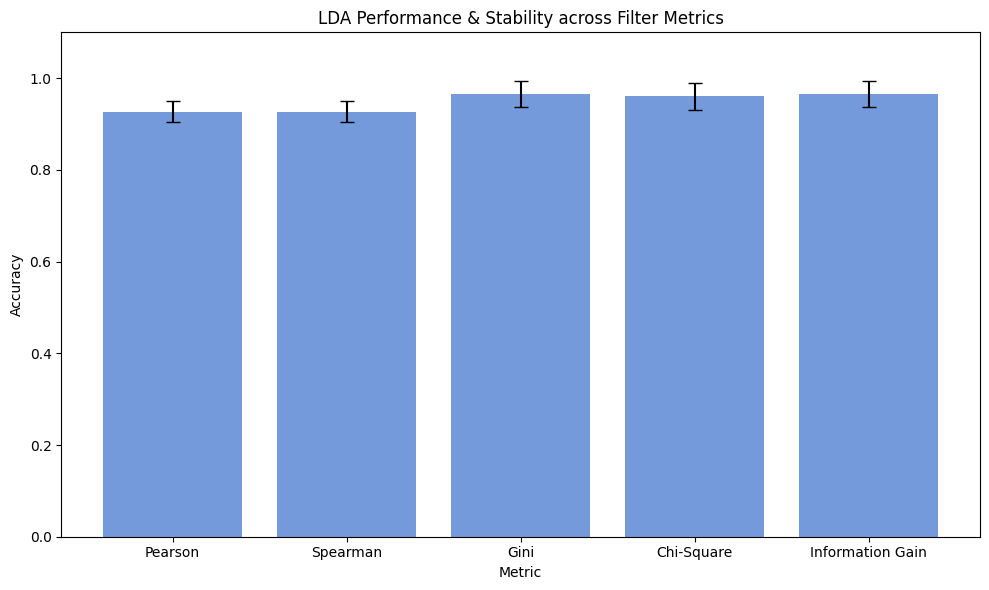

In [9]:
# Evaluate stability and performance using cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for metric, features in top_k_features.items():
    X_subset = df[features].values
    y_vals = df['target'].values
    
    fold_accuracies = []
    
    for train_index, test_index in skf.split(X_subset, y_vals):
        X_train, X_test = X_subset[train_index], X_subset[test_index]
        y_train, y_test = y_vals[train_index], y_vals[test_index]
        
        # Train LDA using at most C-1 components (Wine dataset has 3 classes, so n_components=2)
        lda = LDA(n_components=2)
        lda.fit(X_train, y_train)
        y_pred = lda.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        fold_accuracies.append(acc)
        
    results.append({
        'Metric': metric,
        'Mean CV Accuracy': np.mean(fold_accuracies),
        'CV Std / Stability': np.std(fold_accuracies)
    })

results_df = pd.DataFrame(results)
display(results_df.sort_values(by='Mean CV Accuracy', ascending=False))

# Plot Stability and Performance
plt.figure(figsize=(10,6))
sns.barplot(x='Metric', y='Mean CV Accuracy', data=results_df, color='cornflowerblue')
plt.errorbar(x=range(len(results_df)), y=results_df['Mean CV Accuracy'], 
             yerr=results_df['CV Std / Stability'], fmt='none', c='black', capsize=5)
plt.title("LDA Performance & Stability across Filter Metrics")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()
